In [1]:
# ============================================================
# 2.1. Nạp thư viện
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, MaxPool2D, Flatten

In [2]:
# ============================================================
# 2.2. Đọc dữ liệu MNIST
# ============================================================

# Load MNIST trực tiếp từ TensorFlow
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Số class từ 0 đến 9
num_classes = 10

# Input shape cho CNN: 28 x 28 x 1
input_shape = (28, 28, 1)

# Chuẩn hóa pixel từ [0,255] về [0,1]
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Thêm chiều channel: từ (60000, 28, 28) -> (60000, 28, 28, 1)
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

print("Sau reshape:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("Number of classes:", len(np.unique(y_train)))
print("Classes:", np.unique(y_train))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
Sau reshape:
X_train: (60000, 28, 28, 1)
X_test: (10000, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]


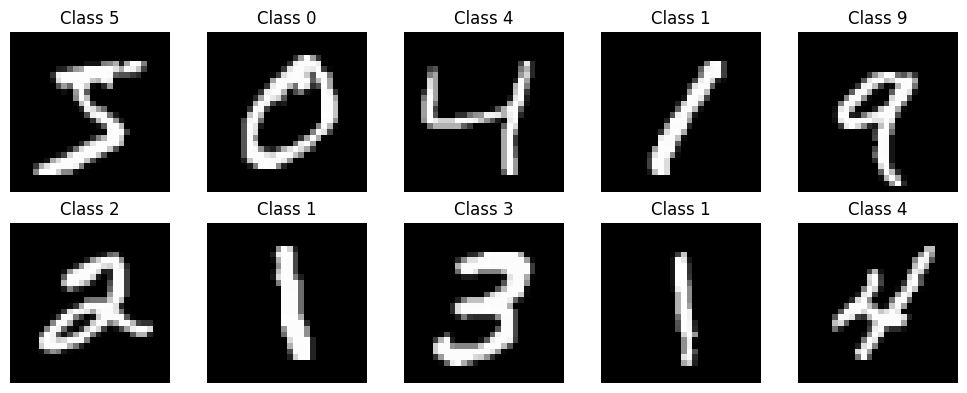

In [3]:
# ============================================================
# 2.3. Trực quan hóa 10 ảnh đầu tiên
# ============================================================

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Class {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# 2.4. Chuyển giá trị nhãn thành one-hot encoding
# ============================================================

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

print("y_train sau one-hot:", y_train.shape)
print("y_test sau one-hot:", y_test.shape)

print("Ví dụ nhãn đầu tiên sau one-hot:")
print(y_train[0])

y_train sau one-hot: (60000, 10)
y_test sau one-hot: (10000, 10)
Ví dụ nhãn đầu tiên sau one-hot:
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [5]:
# ============================================================
# 2.5. Xây dựng mô hình CNN
# ============================================================

model = Sequential()

model.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu",
    input_shape=input_shape
))

model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation="relu"
))

model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Flatten())

model.add(Dense(
    units=num_classes,
    activation="softmax"
))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================================
# 2.6. Huấn luyện mô hình CNN
# ============================================================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_fit = model.fit(
    X_train,
    y_train,
    epochs=15,
    validation_split=0.2,
    verbose=1
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9455 - loss: 0.1829 - val_accuracy: 0.9803 - val_loss: 0.0675
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.9811 - loss: 0.0600 - val_accuracy: 0.9808 - val_loss: 0.0614
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9870 - loss: 0.0423 - val_accuracy: 0.9826 - val_loss: 0.0583
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9894 - loss: 0.0322 - val_accuracy: 0.9853 - val_loss: 0.0460
Epoch 5/15
 814/1500 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9938 - loss: 0.0222

KeyboardInterrupt: 

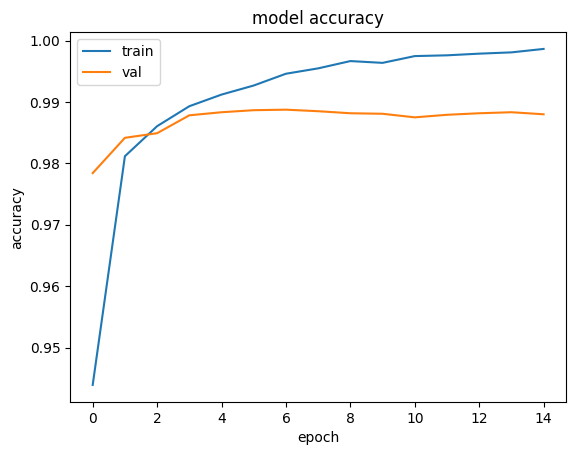

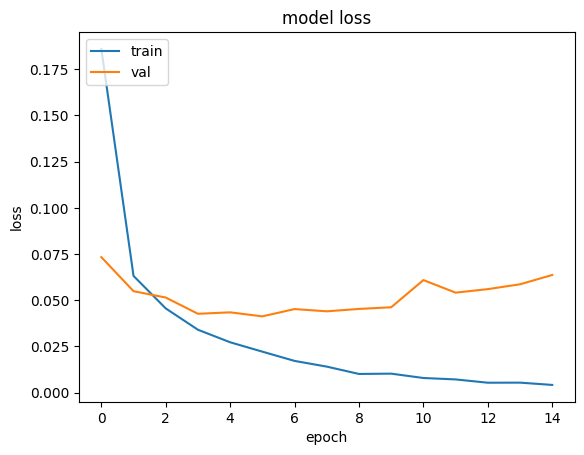

In [ ]:
# ============================================================
# 2.7. Đánh giá mô hình CNN bằng biểu đồ accuracy và loss
# ============================================================

# Biểu đồ accuracy
plt.plot(model_fit.history["accuracy"])
plt.plot(model_fit.history["val_accuracy"])
plt.title("model accuracy")
plt.ylabel("accuracy")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

# Biểu đồ loss
plt.plot(model_fit.history["loss"])
plt.plot(model_fit.history["val_loss"])
plt.title("model loss")
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend(["train", "val"], loc="upper left")
plt.show()

In [ ]:
# ============================================================
# 2.8. Đánh giá mô hình CNN thử nghiệm trên tập test
# ============================================================

score = model.evaluate(X_test, y_test, verbose=1)

print("Test loss:", score[0])
print("Test accuracy:", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9890 - loss: 0.0488
Test loss: 0.04883557930588722
Test accuracy: 0.9890000224113464


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step
Vector xác suất dự báo:
[[9.2167567e-12 4.7045502e-16 1.0000000e+00 4.7813406e-21 1.3112486e-17
  9.1939447e-28 2.8960534e-11 1.8929005e-24 7.3530266e-14 5.8996646e-21]]
Nhãn dự báo: 2
Nhãn thật: 2


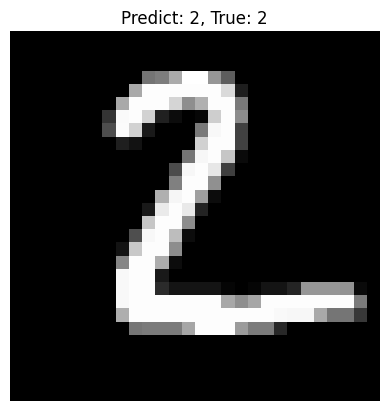

In [ ]:
# ============================================================
# 2.9. Dự báo nhãn cho ảnh sử dụng CNN
# ============================================================

# Dự báo ảnh thứ 1 trong tập test
predict = model.predict(X_test[1:2])

print("Vector xác suất dự báo:")
print(predict)

print("Nhãn dự báo:", np.argmax(predict))
print("Nhãn thật:", np.argmax(y_test[1]))

plt.imshow(X_test[1].reshape(28, 28), cmap="gray")
plt.title(f"Predict: {np.argmax(predict)}, True: {np.argmax(y_test[1])}")
plt.axis("off")
plt.show()

In [9]:
# ============================================================
# 2.10. Lưu tham số mô hình CNN
# ============================================================

model.save_weights("cnn.weights.h5")

print("Đã lưu trọng số mô hình vào file cnn.weights.h5")

Đã lưu trọng số mô hình vào file cnn.weights.h5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Vector xác suất dự báo:
[[1.9561168e-07 9.9984515e-01 7.3833880e-06 6.8134398e-08 8.8691253e-05
  4.6219333e-07 8.6139181e-07 3.1882570e-05 2.3937037e-05 1.3455552e-06]]
Nhãn dự báo: 1
Nhãn thật: 1


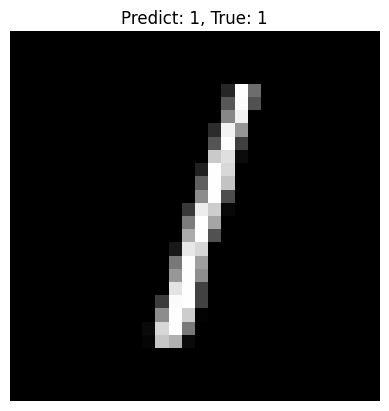

In [10]:
# ============================================================
# 2.11. Nạp lại mô hình và tham số
# ============================================================

# Tạo lại kiến trúc giống y hệt mô hình ban đầu
model_1 = Sequential()

model_1.add(Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu",
    input_shape=input_shape
))

model_1.add(MaxPool2D(pool_size=(2, 2)))

model_1.add(Conv2D(
    filters=64,
    kernel_size=(3, 3),
    activation="relu"
))

model_1.add(MaxPool2D(pool_size=(2, 2)))

model_1.add(Flatten())

model_1.add(Dense(
    units=num_classes,
    activation="softmax"
))

# Nạp trọng số đã lưu
model_1.load_weights("cnn.weights.h5")

# Dự báo lại ảnh thứ 3
predict = model_1.predict(X_test[2:3])

print("Vector xác suất dự báo:")
print(predict)

print("Nhãn dự báo:", np.argmax(predict))
print("Nhãn thật:", np.argmax(y_test[2]))

plt.imshow(X_test[2].reshape(28, 28), cmap="gray")
plt.title(f"Predict: {np.argmax(predict)}, True: {np.argmax(y_test[2])}")
plt.axis("off")
plt.show()